In [1]:
import cv2
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
from google.colab import drive
drive.mount('/content/drive')
!pip install -q opencv-contrib-python-headless==4.10.0.84
!pip install imageio imageio-ffmpeg
import imageio

ModuleNotFoundError: No module named 'cv2'

In [ ]:
def show_roi_on_first_frame(video_path, bbox):
    """
    Displays the first frame of the video with the ROI drawn.

    Parameters:
        video_path (str): Path to video file
        bbox (tuple): (x, y, width, height)
    """

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise Exception("Could not open video")

    ok, frame = cap.read()
    cap.release()

    if not ok:
        raise Exception("Could not read first frame")

    x, y, w, h = bbox

    # Draw rectangle
    cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 3)

    # Convert BGR → RGB for display
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8,6))
    plt.imshow(frame_rgb)
    plt.title("First Frame with ROI")
    plt.axis("off")
    plt.show()

In [ ]:
video_path = "/content/drive/MyDrive/Colab Notebooks/Copy of IMG_8545.mov"

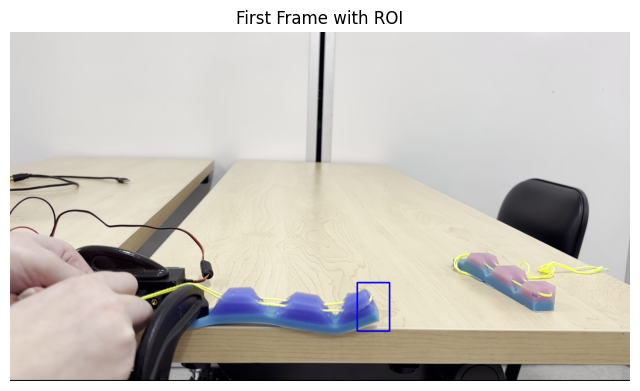

In [ ]:
# ROI format: (x, y, width, height)
# origin is the upper left corner of the frame, X is positive to the right, Y is positive downward
bbox = (1075, 775, 100, 150)   # <-- CHANGE THIS
show_roi_on_first_frame(video_path, bbox)

In [ ]:
# -------- USER INPUT --------
tracker_type = "CSRT"
output_path = "/content/drive/MyDrive/output_tracked.mp4"
output_csv = "/content/drive/MyDrive/output_tracked.csv"
max_frames = 800   # <-- Set to None to process entire video


In [ ]:
# Open video
video = cv2.VideoCapture(video_path)
if not video.isOpened():
    raise Exception("Could not open video")

total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
fps_input = video.get(cv2.CAP_PROP_FPS)
width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"Total frames in video: {total_frames}")

if max_frames is None:
    frames_to_process = total_frames
else:
    frames_to_process = min(max_frames, total_frames)
print(f"Processing {frames_to_process} frames...")

# Read first frame
ok, frame = video.read()
(major_ver, minor_ver, subminor_ver) = (cv2.__version__).split('.')
if int(major_ver) < 4 and int(minor_ver) < 3:
    tracker = cv2.cv2.Tracker_create(tracker_type)
else:
    if tracker_type == 'BOOSTING':
        tracker = cv2.TrackerBoosting_create()
    if tracker_type == 'MIL':
        tracker = cv2.TrackerMIL_create()
    if tracker_type == 'KCF':
        tracker = cv2.TrackerKCF_create()
    if tracker_type == 'TLD':
        tracker = cv2.TrackerTLD_create()
    if tracker_type == 'MEDIANFLOW':
        tracker = cv2.legacy.TrackerMedianFlow_create()
    if tracker_type == 'CSRT':
        tracker = cv2.TrackerCSRT_create()
    if tracker_type == 'MOSSE':
        tracker = cv2.TrackerMOSSE_create()

bbox = tuple(int(v) for v in bbox)
init_success = tracker.init(frame, bbox)
frames_for_video = []

# Write first frame
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
frames_for_video.append(frame_rgb)

pts = []
frame_number = 0
fail_count = 0

# Tracking loop
while frame_number < frames_to_process:
    ok, frame = video.read()
    if not ok:
        break
    success, bbox = tracker.update(frame)
    if success:
        x, y, w, h = [int(v) for v in bbox]

        # Use center of box for displacement tracking
        center_x = x + w / 2
        center_y = y + h / 2
        pts.append([center_x, center_y])
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
    else:
        fail_count += 1
        cv2.putText(frame, "Tracking failure", (100,80),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.75,(0,0,255),2)
    cv2.putText(frame, f"Frame: {frame_number+1}/{frames_to_process}", (20,30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (50,170,50),2)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frames_for_video.append(frame_rgb)
    frame_number += 1
    # Print progress every 50 frames
    if frame_number % 50 == 0 or frame_number == frames_to_process:
        percent = (frame_number / frames_to_process) * 100
        print(f"Processed {frame_number}/{frames_to_process} ({percent:.1f}%)")

imageio.mimsave(
    output_path,
    frames_for_video,
    fps=fps_input,
    codec="libx264")

pts = np.array(pts)
np.savetxt(output_csv, pts, delimiter=",")

print("\nTracking complete.")
print("Tracking failures:", fail_count)
print("Successful frames:", len(pts))

Total frames in video: 2873
Processing 800 frames...
Processed 50/800 (6.2%)
Processed 100/800 (12.5%)
Processed 150/800 (18.8%)
Processed 200/800 (25.0%)
Processed 250/800 (31.2%)
Processed 300/800 (37.5%)
Processed 350/800 (43.8%)
Processed 400/800 (50.0%)
Processed 450/800 (56.2%)
Processed 500/800 (62.5%)
Processed 550/800 (68.8%)
Processed 600/800 (75.0%)
Processed 650/800 (81.2%)
Processed 700/800 (87.5%)
Processed 750/800 (93.8%)


Processed 800/800 (100.0%)

Tracking complete.
Tracking failures: 0
Successful frames: 800


In [ ]:
from IPython.display import HTML
from base64 import b64encode


with open(output_path, "rb") as f:
    video_bytes = f.read()

video_base64 = b64encode(video_bytes).decode()

HTML(f"""
<video width=800 controls>
    <source src="data:video/mp4;base64,{video_base64}" type="video/mp4">
</video>
""")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Ensure pts is numpy array
x_positions = pts[:, 0]
y_positions = pts[:, 1]
frames = np.arange(len(pts))  # z-axis = frame index

fig = go.Figure(data=[
    go.Scatter3d(
        x=x_positions,
        y=y_positions,
        z=frames,
        mode='lines',
        line=dict(
            width=6,
            color=frames,          # color by time
            colorscale='Viridis'
        )
    )
])

fig.update_layout(
    title="3D Trajectory (X, Y, Frame)",
    dragmode='orbit',   # ✅ orbital rotation
    scene=dict(
        xaxis_title='X Position',
        yaxis_title='Y Position',
        zaxis=dict(title='Frame'),
        camera=dict(
            eye=dict(x=.1, y=-0.1, z=-2.5),
            up=dict(x=0, y=-1, z=0)
        )
    ),
    width=900,
    height=700
)

fig.show()

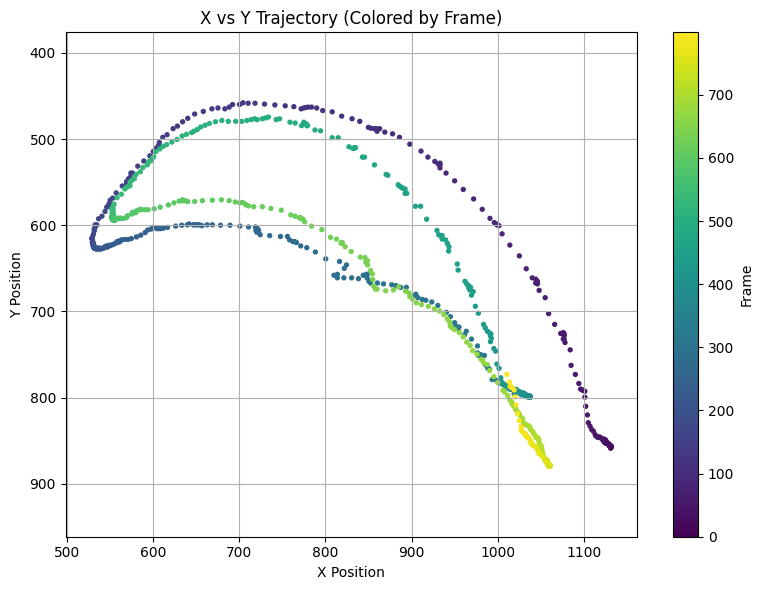

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

pts = np.array(pts)

if len(pts) == 0:
    raise ValueError("pts is empty — tracking likely failed.")

x_positions = pts[:, 0]
y_positions = pts[:, 1]
frames = np.arange(len(pts))

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    x_positions,
    y_positions,
    c=frames,
    cmap='viridis',
    s=8
)

plt.colorbar(scatter, label='Frame')

plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("X vs Y Trajectory (Colored by Frame)")

# Match image coordinate system (Y increases downward)
plt.gca().invert_yaxis()
plt.grid(True)
plt.axis('equal')   # keep correct aspect ratio
plt.tight_layout()
plt.show()

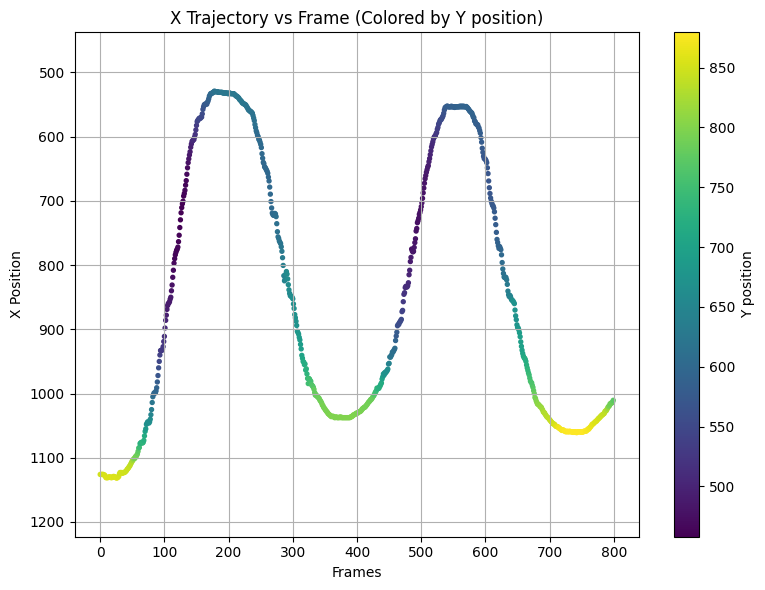

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

pts = np.array(pts)

if len(pts) == 0:
    raise ValueError("pts is empty — tracking likely failed.")

x_positions = pts[:, 0]
y_positions = pts[:, 1]
frames = np.arange(len(pts))

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    frames,
    x_positions,
    c=y_positions,
    cmap='viridis',
    s=8
)

plt.colorbar(scatter, label='Y position')

plt.xlabel("Frames")
plt.ylabel("X Position")
plt.title("X Trajectory vs Frame (Colored by Y position)")

# Match image coordinate system (Y increases downward)
plt.gca().invert_yaxis()
plt.grid(True)
plt.axis('equal')   # keep correct aspect ratio
plt.tight_layout()
plt.show()

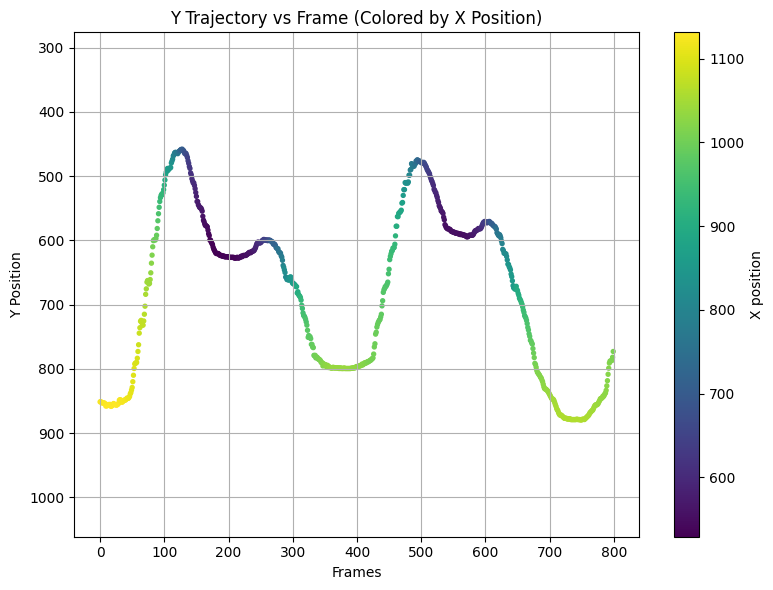

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

pts = np.array(pts)

if len(pts) == 0:
    raise ValueError("pts is empty — tracking likely failed.")

x_positions = pts[:, 0]
y_positions = pts[:, 1]
frames = np.arange(len(pts))

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    frames,
    y_positions,
    c=x_positions,
    cmap='viridis',
    s=8
)

plt.colorbar(scatter, label='X position')

plt.xlabel("Frames")
plt.ylabel("Y Position")
plt.title("Y Trajectory vs Frame (Colored by X Position)")

# Match image coordinate system (Y increases downward)
plt.gca().invert_yaxis()
plt.grid(True)
plt.axis('equal')   # keep correct aspect ratio
plt.tight_layout()
plt.show()